**Baixar base de dados**

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_ab31b5b18c50a9012fc128a74e2de02a"


In [ ]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token


In [ ]:
!pip install kaggle

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:08<00:00, 20.0MB/s]



Teste da base e imagens

In [ ]:
!ls /content

brain-tumor-mri-dataset.zip  sample_data  Testing  Training


In [ ]:
!ls /content/Training


glioma	meningioma  notumor  pituitary


**train_data e val_data**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

dataset_path = "/content/Training"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


Teste das Imagens

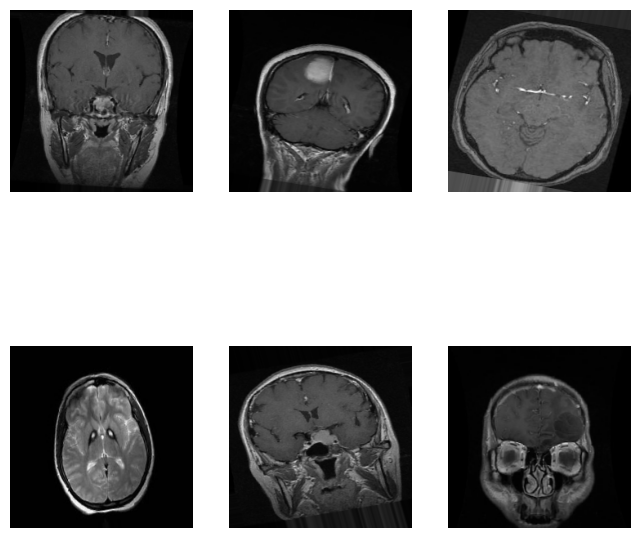

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()


In [ ]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**CRIAR O MODELO**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # congelar as camadas pré-treinadas

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**COMPILAR MODELO**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

**TREINAMENTO**

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7522 - loss: 0.6350 - val_accuracy: 0.8375 - val_loss: 0.4241 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.8397 - loss: 0.4080 - val_accuracy: 0.8571 - val_loss: 0.3677 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.8605 - loss: 0.3643 - val_accuracy: 0.8821 - val_loss: 0.3143 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.8757 - loss: 0.3328 - val_accuracy: 0.8545 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.8757 - loss: 0.3178 - val_accuracy: 0.8607 - val_loss: 0.3553 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.8935 - loss: 0.2867 - val_accuracy: 0.8687 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.8996 - loss: 0.

In [ ]:
best_epoch = history.history['val_accuracy'].index(
    max(history.history['val_accuracy'])
)

print("Melhor época:", best_epoch + 1)

Melhor época: 13


**Gráficos**

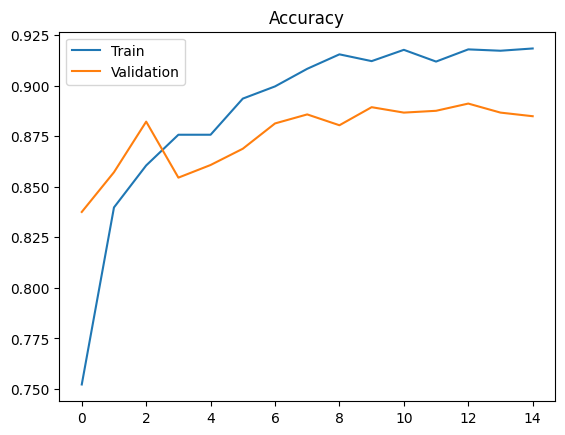

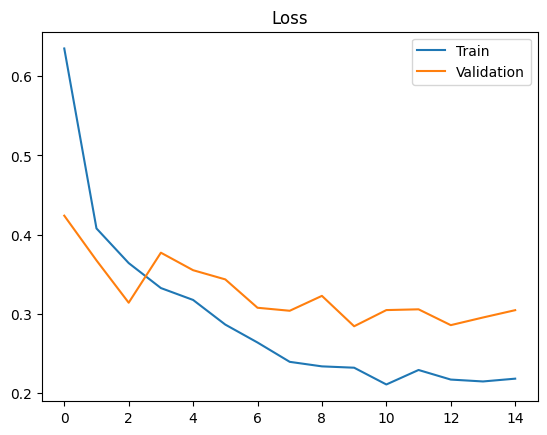

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss')
plt.show()

**AVALIAÇÃO FINAL**

In [ ]:
loss, acc = model.evaluate(val_data)
print(f"Acurácia final: {acc:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8893 - loss: 0.2846
Acurácia final: 0.8893


Salvar e Baixar Modelo

In [ ]:
model.save("brain_tumor_model_project.h5")

In [ ]:
from google.colab import files
files.download("brain_tumor_model_project.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save("/content/drive/MyDrive/brain_tumor_model_project.h5")